In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('Diwali Sales Data.csv',encoding='unicode_escape')

In [4]:
df.shape

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [9]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [11]:
pd.isnull(df)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [13]:
# to drop null values
df.dropna(inplace=True)

In [14]:
df.shape

(11239, 13)

In [15]:
# change data type
df['Amount']=df['Amount'].astype('int')

In [16]:
df['Amount'].dtype

dtype('int64')

In [17]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [18]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


# Exploratory data analysis

### gender

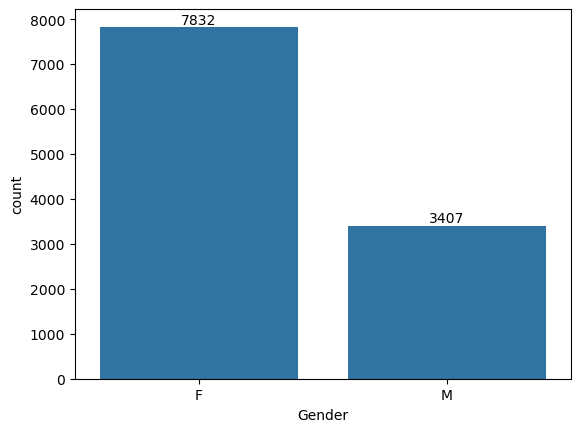

In [20]:
ax=sns.countplot(x='Gender',data =df)

for bars in ax.containers:
    ax.bar_label(bars)

from above it can be concluded that women are twice times more involved in shopping then males

<Axes: xlabel='Gender', ylabel='Amount'>

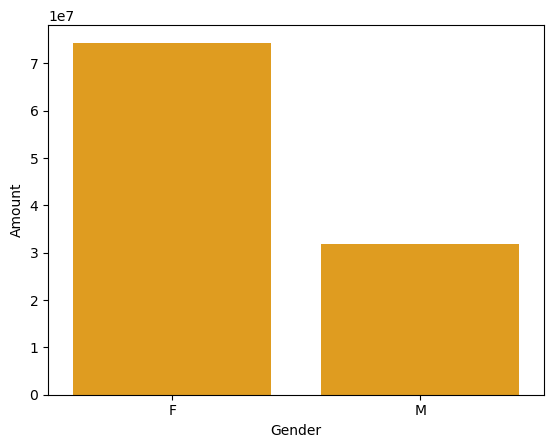

In [29]:
gender_sales = df.groupby(["Gender"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=gender_sales, x="Gender", y="Amount",color='orange')



from above fraph we can see that most buyers are females and also there purchasing power is more than the males 

## Age

<Axes: xlabel='Age Group', ylabel='count'>

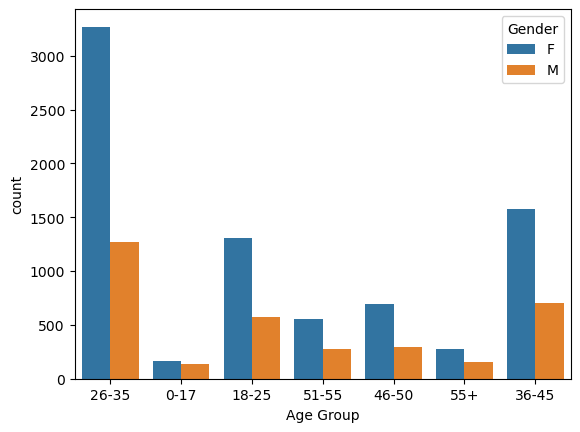

In [34]:
sns.countplot(data=df,x='Age Group',hue='Gender')

<Axes: xlabel='Age Group', ylabel='Amount'>

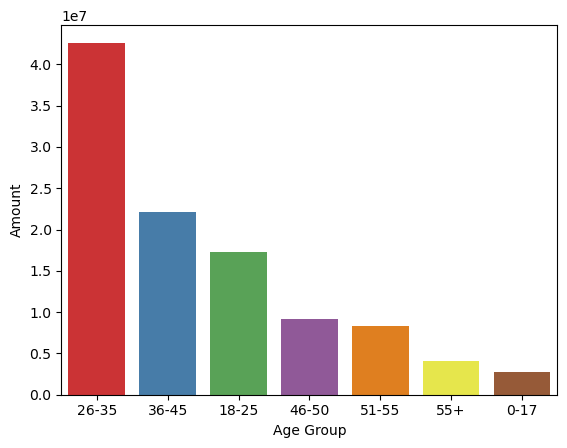

In [39]:
age_sales = df.groupby(["Age Group"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False)

sns.barplot(data=age_sales, x="Age Group", y="Amount",palette="Set1",hue='Age Group')



most of the buyers are of age group between 26-35 yrs females

## States

<Axes: xlabel='State', ylabel='Orders'>

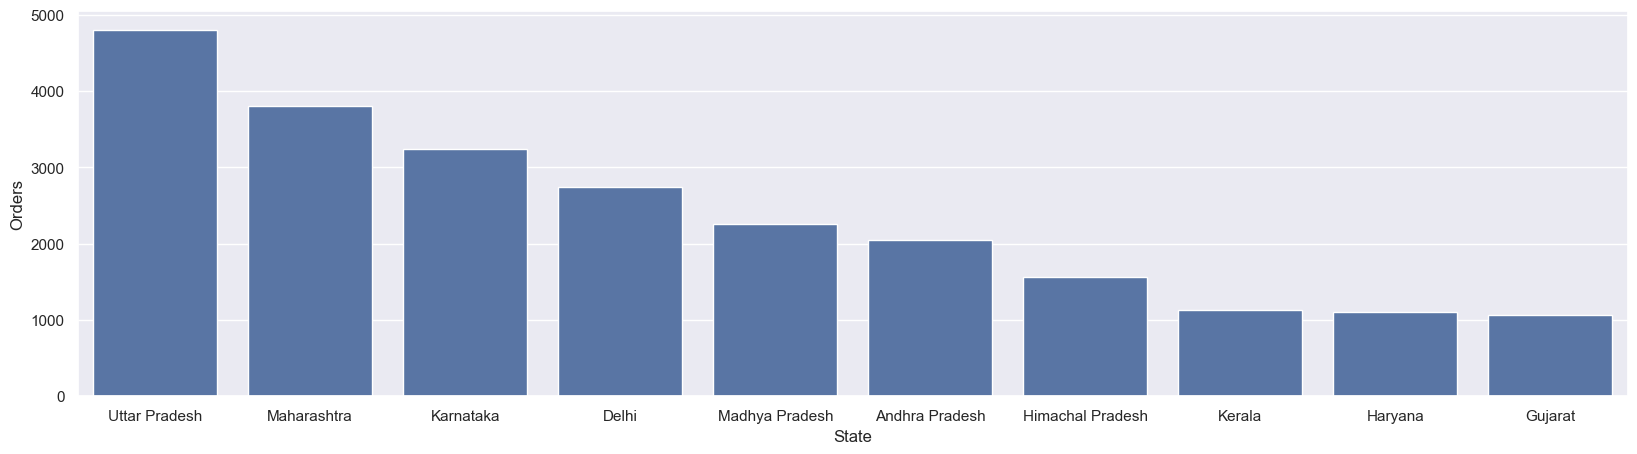

In [49]:
# totol numbers of orders from top 10 states

sales_states = df.groupby(["State"],as_index=False)["Orders"].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_states, x="State", y="Orders")



<Axes: xlabel='State', ylabel='Amount'>

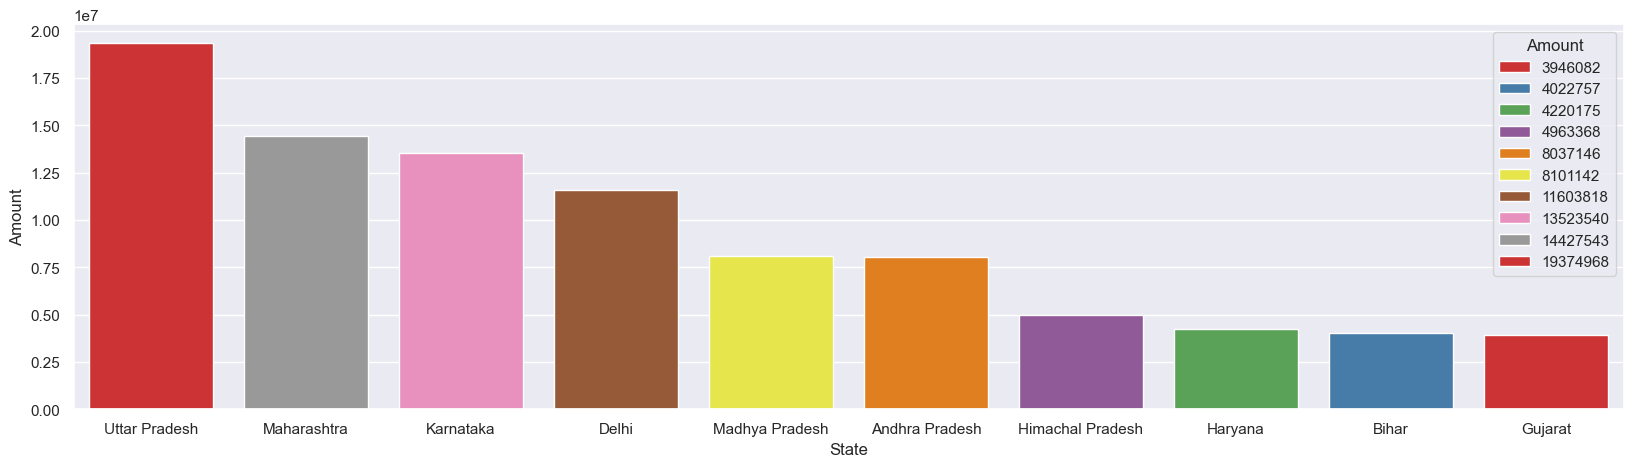

In [56]:
# total sales/amount from top 10 states

sales_states = df.groupby(["State"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_states, x="State", y="Amount" ,hue='Amount',palette="Set1")




Uttar Pradesh ,Maharashtra abd Karnataka are top states with most orders 

## Marital Status

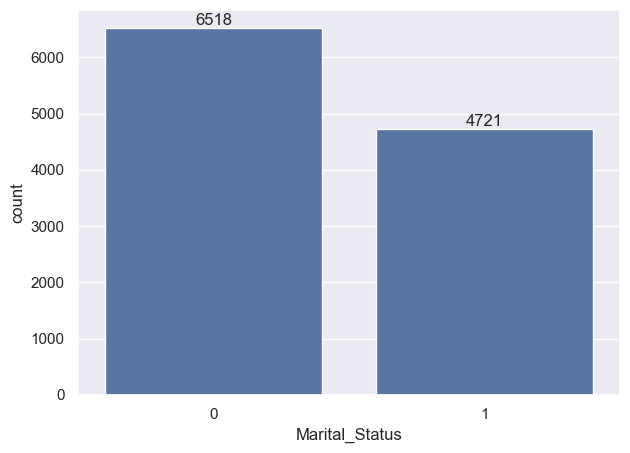

In [60]:
bx=sns.countplot(x='Marital_Status',data =df)
sns.set(rc={'figure.figsize':(10,5)})
for bars in bx.containers:
    bx.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

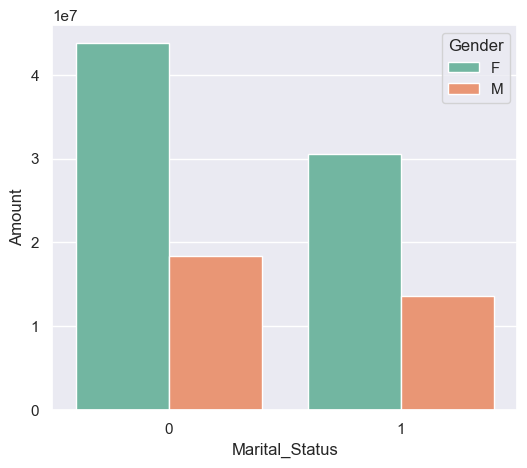

In [66]:
sales_marital = df.groupby(["Marital_Status","Gender"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(6,5)}) ,
sns.barplot(data=sales_marital, x="Marital_Status", y="Amount" ,hue='Gender',palette="Set2")


most of the buyers are married(women) and they have high purchasing power

## Occupation

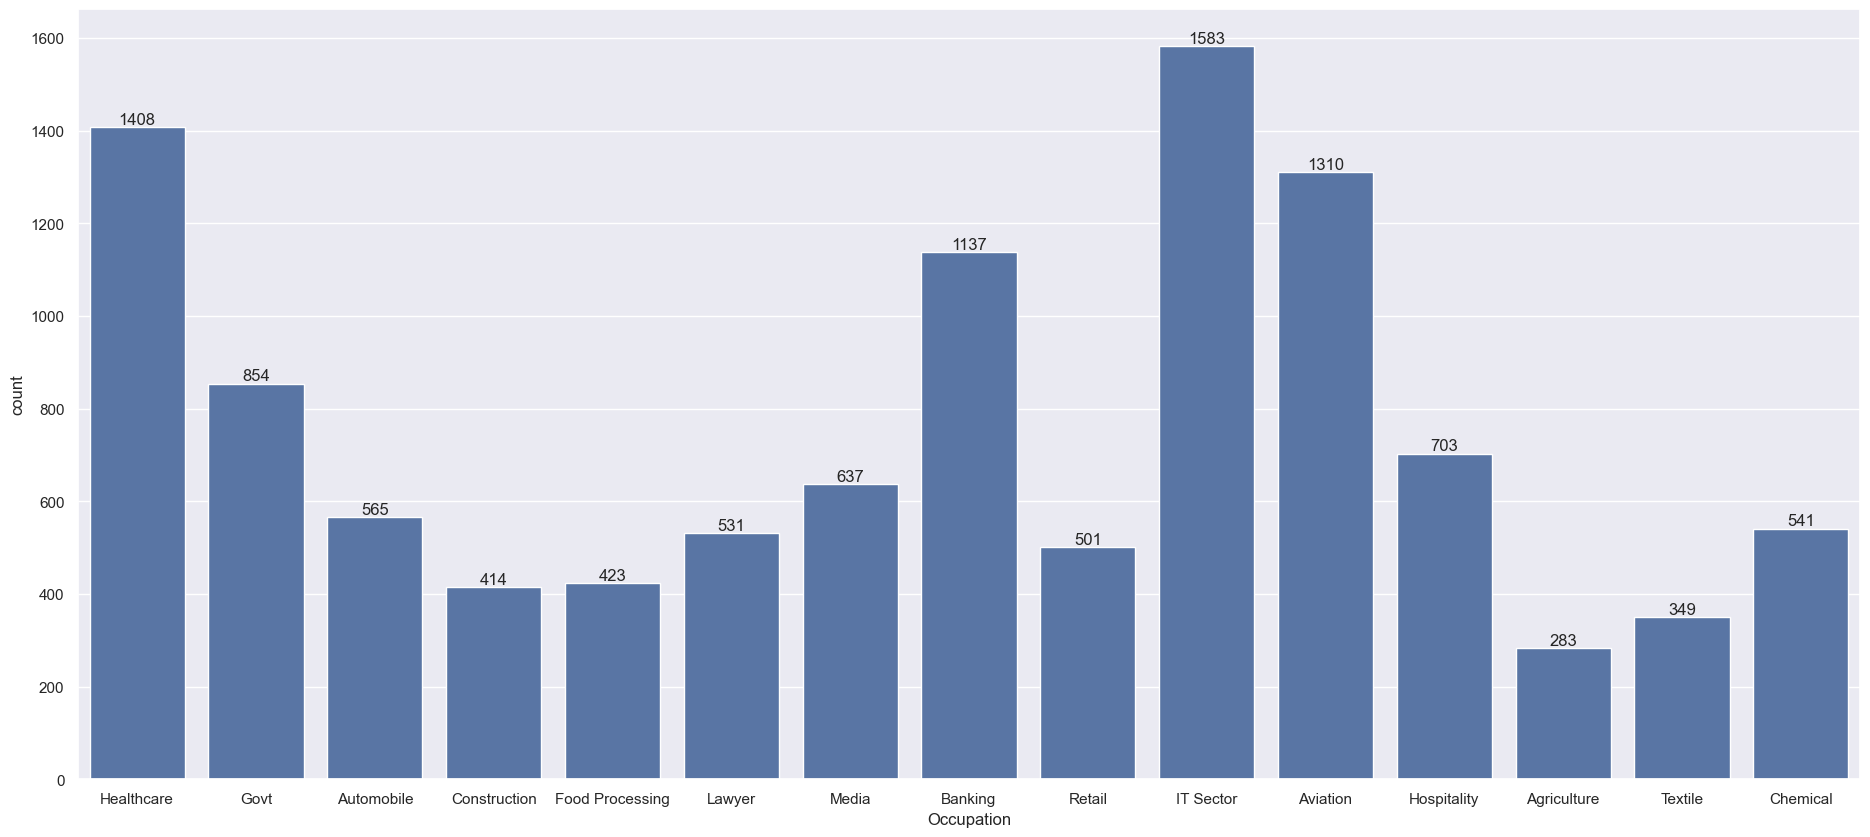

In [73]:
bx=sns.countplot(x='Occupation',data =df)
sns.set(rc={'figure.figsize':(23,15)})
for bars in bx.containers:
    bx.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

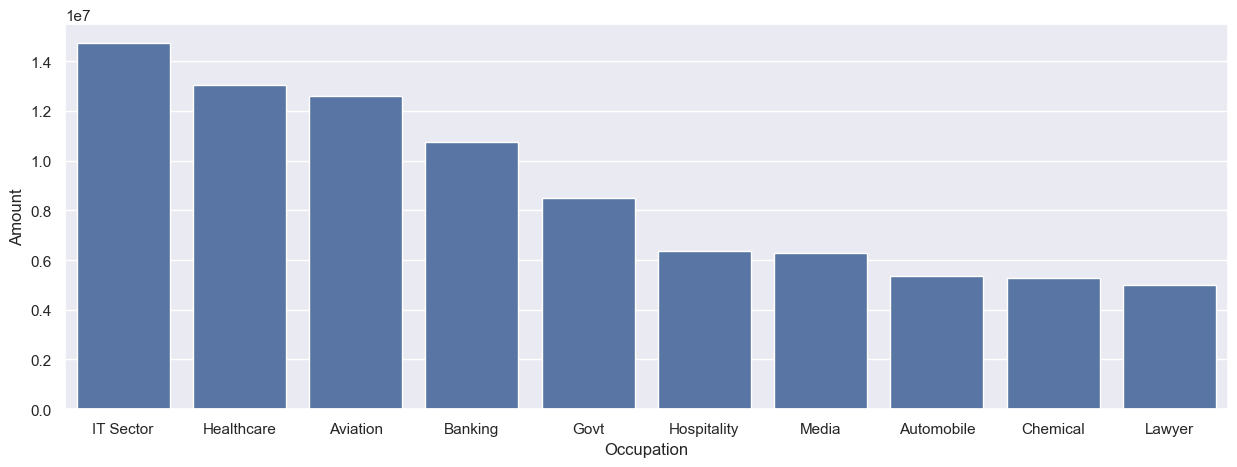

In [76]:
sales_occu = df.groupby(["Occupation"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)}) ,
sns.barplot(data=sales_occu, x="Occupation", y="Amount")


we can conclude that most buyers are working in IT ,Aviation and Healthcare sector

## Product Category

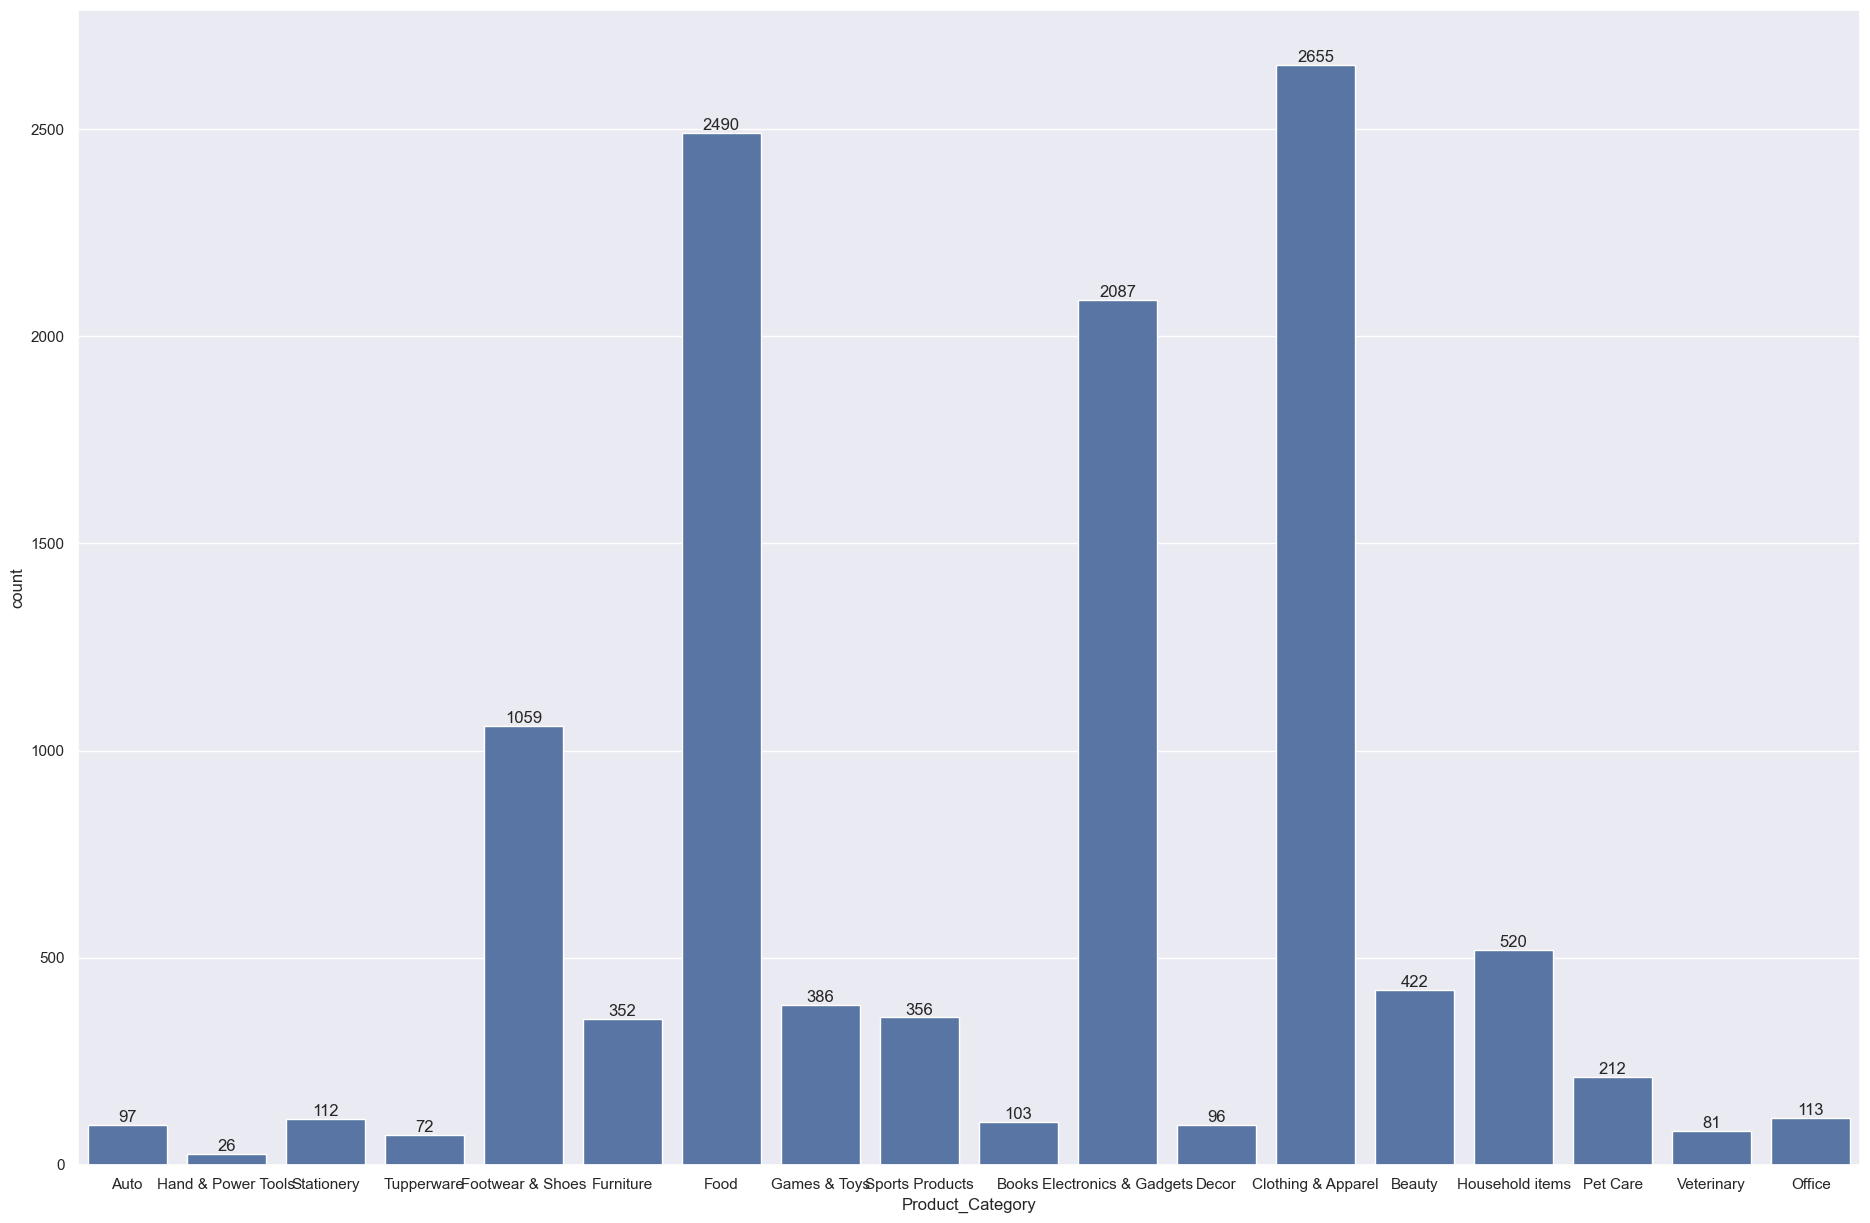

In [78]:
bx=sns.countplot(x='Product_Category',data =df)
sns.set(rc={'figure.figsize':(13,7)})
for bars in bx.containers:
    bx.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

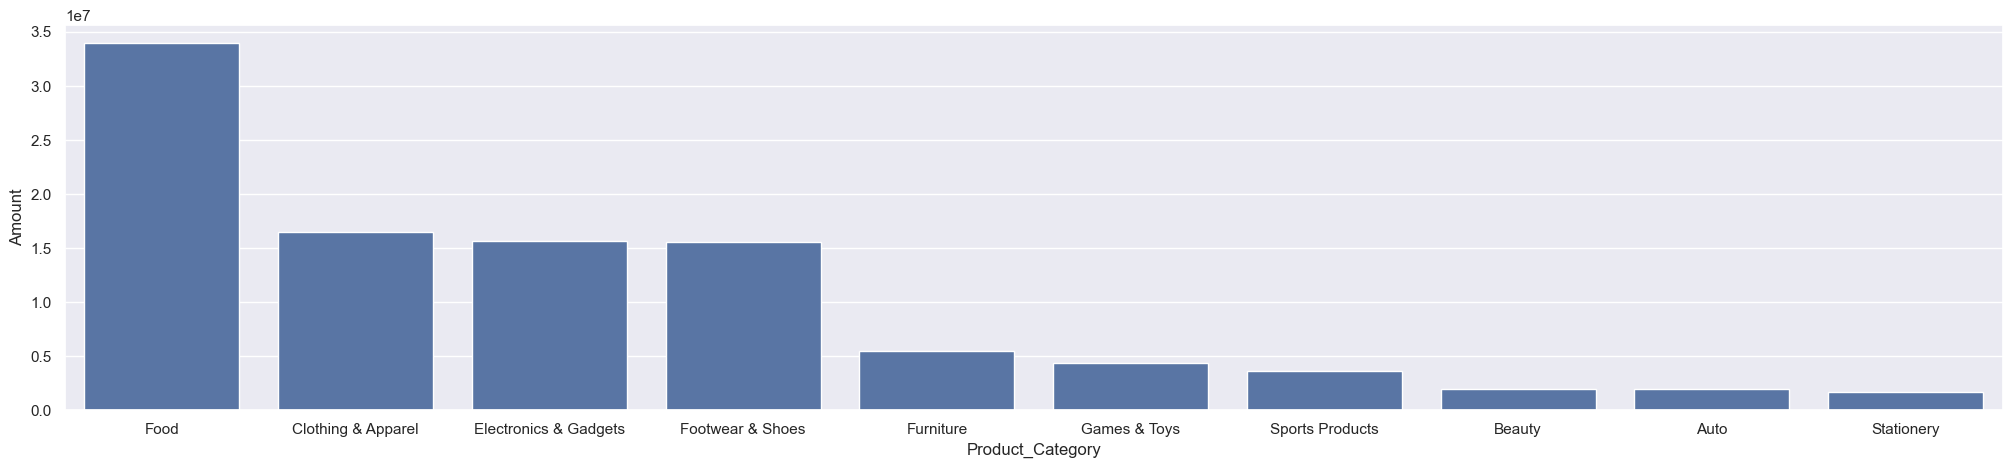

In [81]:
sales_occu = df.groupby(["Product_Category"],as_index=False)["Amount"].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(25,5)}) ,
sns.barplot(data=sales_occu, x="Product_Category", y="Amount")


From the above graphs we can see that most of the sold products are Food ,Footwear and Electronics category

<Axes: xlabel='Product_ID', ylabel='Orders'>

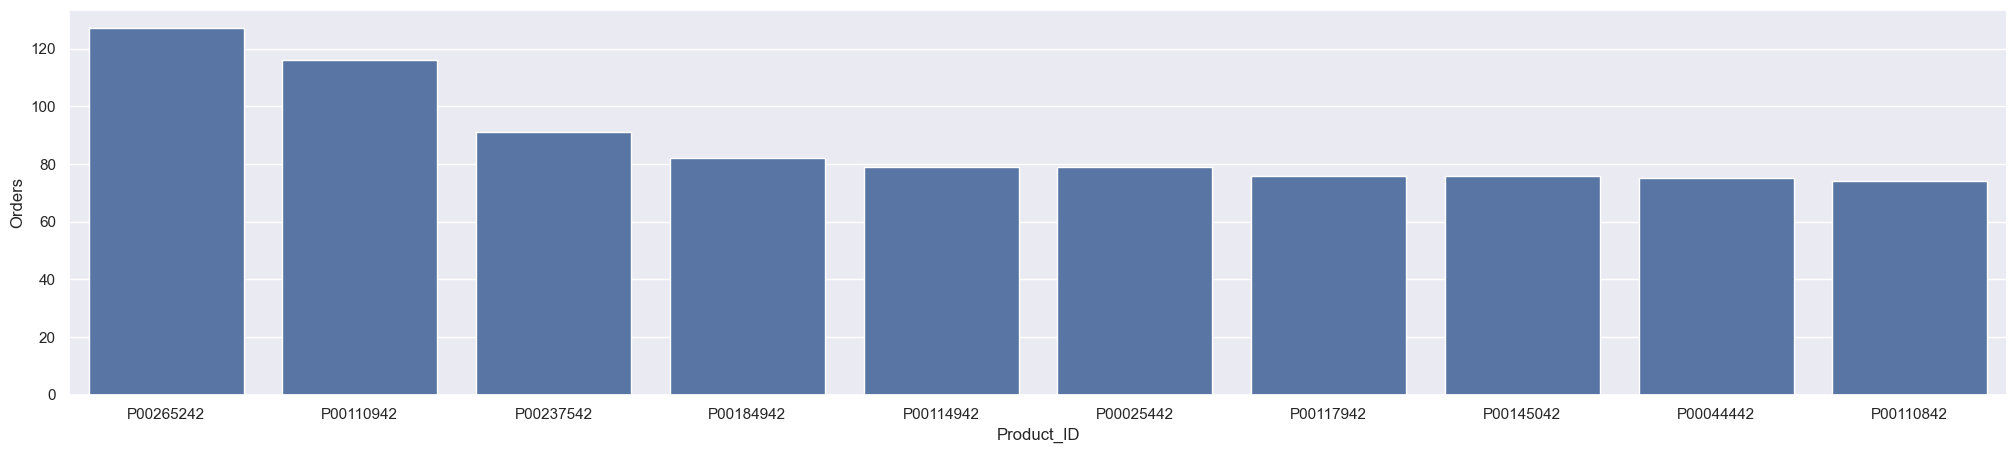

In [83]:
# the top 10 most selling produts 
sales_occu = df.groupby(["Product_ID"],as_index=False)["Orders"].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(25,5)}) ,
sns.barplot(data=sales_occu, x="Product_ID", y="Orders")


## Conclusion

Married women age group 26-35 yrs from UP, Maharashtra and Karnataka working in IT ,Heatlthcare and Aviation are more likely to buy products from Food ,Clothing and Electronics category